<a href="https://colab.research.google.com/github/Nivetha-B93/Linear_regression/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/mobile_price.csv')
df

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.20,424,8,1.350,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.70,312,4,1.200,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.00,233,2,1.300,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1206,3551,4638,178.0,5.46,538,4,1.875,128.0,6.000,12.00,16.0,4080,8.4
157,1296,3211,8016,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9
158,856,3260,8809,150.0,5.50,401,8,2.200,64.0,4.000,20.00,20.0,3000,6.8
159,1296,3211,8946,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9


## **Inspect dataset shape, columns, data types, and missing values**

In [4]:
df.shape

(161, 14)

In [5]:
df.columns

Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='object')

In [6]:
df.dtypes

,0
Product_id,int64
Price,int64
Sale,int64
weight,float64
resoloution,float64
ppi,int64
cpu core,int64
cpu freq,float64
internal mem,float64
ram,float64


In [7]:
df.isnull().sum()

,0
Product_id,0
Price,0
Sale,0
weight,0
resoloution,0
ppi,0
cpu core,0
cpu freq,0
internal mem,0
ram,0


# **Generate statistical summaries for numerical features**

In [8]:
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


## **Create a correlation heatmap focusing on Price**

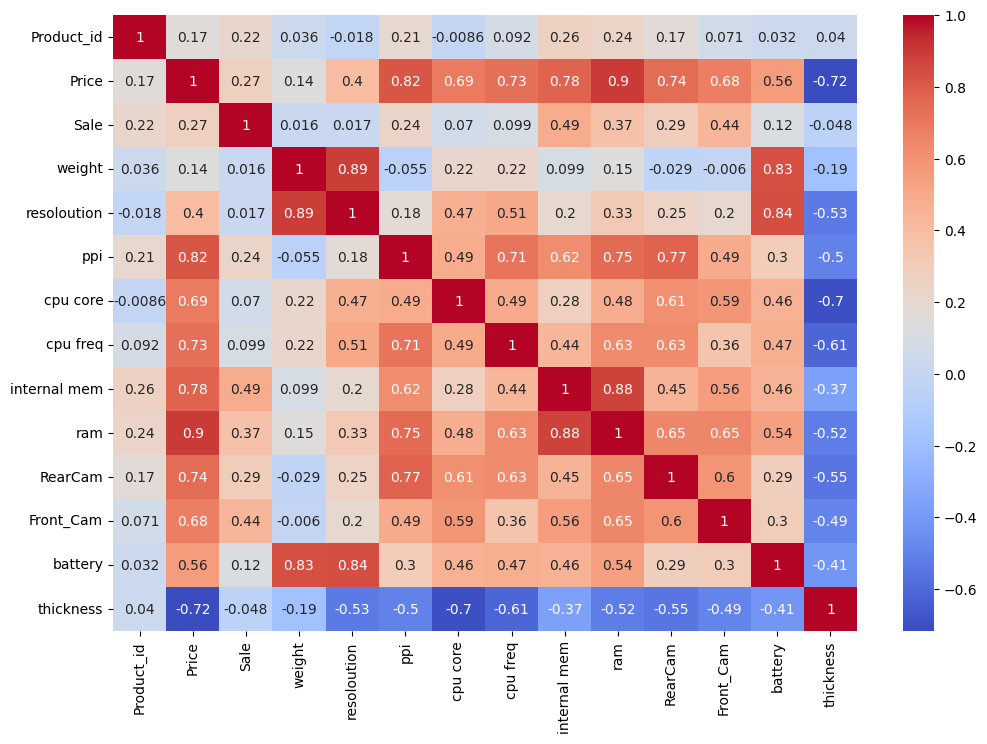

In [10]:
corr=df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr,cmap="coolwarm",annot=True)
plt.show()

# **Identify the top 4 features most correlated with Price**

In [11]:
price_corr = df.corr(numeric_only=True)['Price']

top_4_features = price_corr.drop('Price').abs().sort_values(ascending=False).head(4).index

print(price_corr[top_4_features])

ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
Name: Price, dtype: float64


# **Plot scatter plots for these features against Price and analyze the relationships**

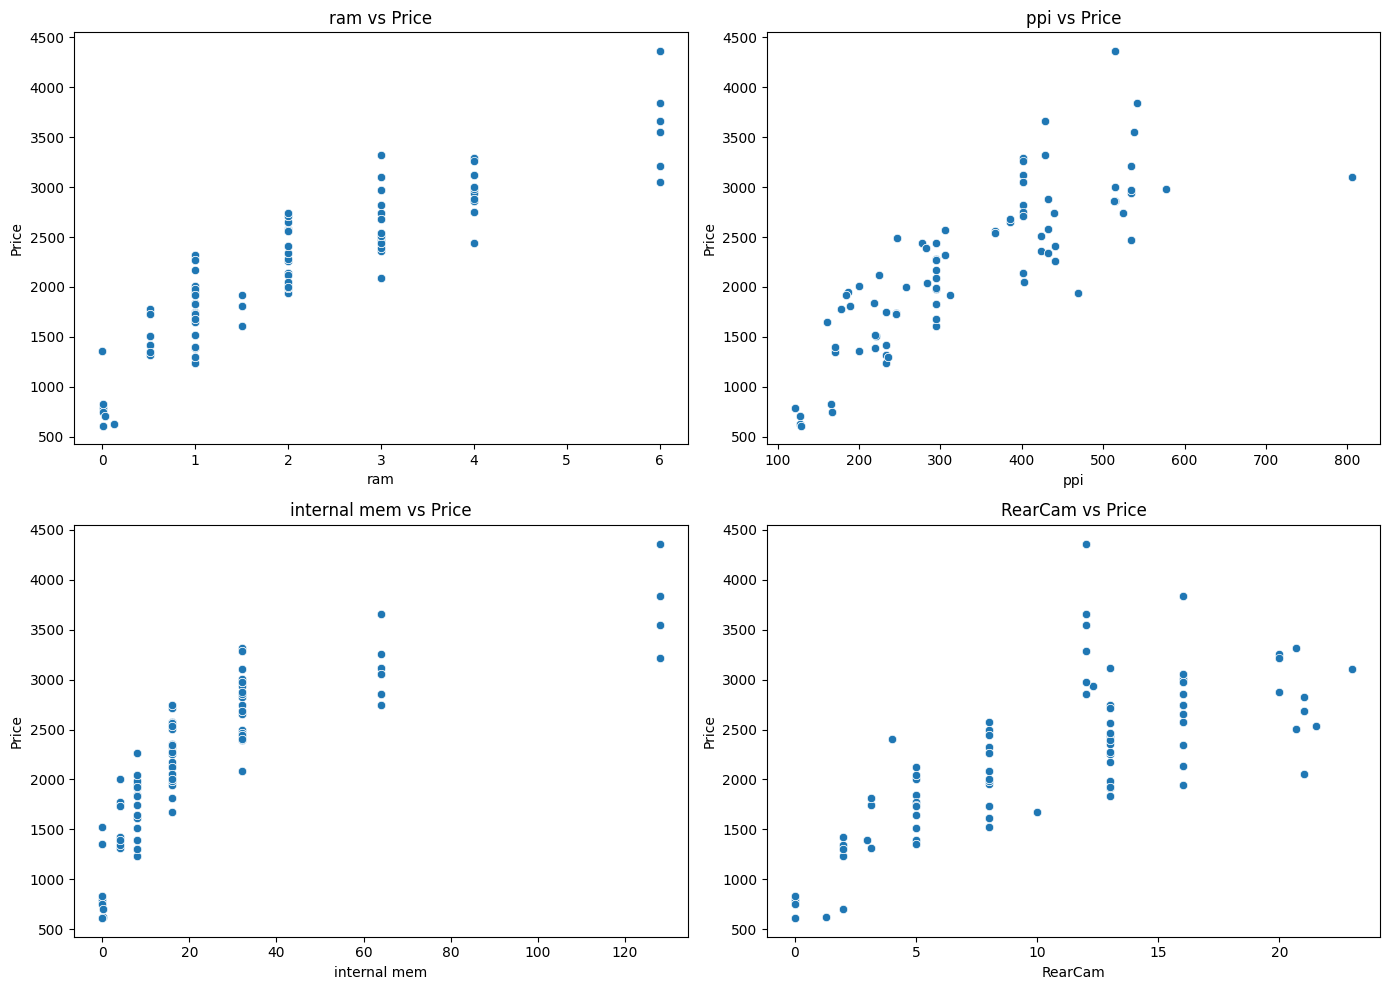

In [12]:

# Create scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, top_4_features):
    sns.scatterplot(data=df, x=feature, y='Price', ax=ax)
    ax.set_title(f'{feature} vs Price')
    ax.set_xlabel(feature)
    ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

RAM vs Price: Strong positive relationship. Higher RAM generally means higher Price.
PPI vs Price: Positive relationship, but the points are more scattered.
Internal Memory vs Price: Strong positive relationship. Higher storage generally leads to higher Price.
RearCam vs Price: Positive relationship, but there is more variation in Price

# **2. Prepare the Data:**
2.1. Feature Selection: Select the features and the target variable for your analysis.

In [13]:
X = df[['ram', 'ppi', 'internal mem', 'RearCam']]
y = df['Price']

2.2. Split the Dataset: Divide the dataset into training and testing sets. Use 80% of the data for
training and 20% for testing.

In [14]:
# Split the dataset
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16)

In [15]:
X_train.shape

(128, 4)

In [16]:
X_test.shape

(33, 4)

In [17]:
y_train.shape

(128,)

In [18]:
y_test.shape

(33,)

3. Build and Train the Model:
3.1. Create a Linear Regression Model: Build a linear regression model using the training data.
3.2. Train the Model: Fit the model to the training data.

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [21]:
X_train

,ram,ppi,internal mem,RearCam
87,6.000,541,128.000,16.0
77,1.000,170,4.000,3.0
63,1.000,306,16.000,8.0
91,1.000,294,8.000,13.0
118,2.000,403,16.000,21.0
...,...,...,...,...
125,0.032,128,0.128,2.0
123,2.000,258,16.000,8.0
65,3.000,401,32.000,21.0
69,1.000,306,16.000,8.0


In [22]:
y_train

,Price
87,3837
77,1396
63,2323
91,1831
118,2054
...,...
125,705
123,2001
65,2824
69,2323


4.1. Predict: Use the model to make predictions on the test set.

In [23]:
y_pred=model.predict(X_test)

Metrics Calculation: Evaluate the model’s performance using the following metrics:
❖ Slope (Coefficient) and Intercept: Print the slope (coefficient) and intercept of the
regression line.

In [24]:
print(f'Intercept {model.intercept_}')
print(f'coefficient={model.coef_}')

Intercept 933.487465258411
coefficient=[252.37515753   1.22614059   3.38002558  20.64711198]


❖❖ Mean Absolute Error (MAE): What is the average absolute difference between predicted
and actual values?
❖ Mean Squared Error (MSE): What is the average of the squared differences between
predicted and actual values? Model Performance Metrics: Calculate and report the following metrics:
❖ R2 Score: How well does the model explain the variance in the target variable?


In [25]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

print(f'Mean Squared Error ={mean_squared_error(y_test,y_pred)}')
print(f'Mean absolute Error ={mean_absolute_error(y_test,y_pred)}')
print(f'R2_score ={r2_score(y_test,y_pred)}')

Mean Squared Error =92877.4106223778
Mean absolute Error =252.5086796613196
R2_score =0.8111785992209084


Model Performance Metrics
Mean Absolute Error (MAE) = 252.51
On average, the model's predicted Price differs from the actual Price by approximately 252.51 units.
Mean Squared Error (MSE) = 92,877.41
The average of the squared differences between the predicted and actual Prices is 92,877.41. Since the errors are squared, larger errors have a greater impact on this metric.
R² Score = 0.8112
The model explains approximately 81.12% of the variance in Price. The remaining 18.88% is not explained by the model

5.2. Insights and Discussion:
❖ What insights did you gain from the correlation analysis and scatter plots?

RAM, Internal Memory, PPI, and RearCam showed positive relationships with mobile Price.
RAM and Internal Memory showed the clearest/strongest relationships with Price.
The scatter plots showed that phones with higher specifications generally tend to have higher prices.
However, there was some variation and scattering, indicating that Price depends on multiple features, not just one feature.
Overall, the correlation analysis helped identify the most relevant features for predicting mobile prices

2.How do the selected features contribute to the prediction of mobile prices?

The selected features contribute to predicting mobile prices as follows:

RAM: Higher RAM is generally associated with higher mobile prices.
Internal Memory: Greater storage capacity tends to increase the price.
PPI: Higher display pixel density is generally associated with higher prices.
RearCam: Better rear-camera specifications tend to be associated with higher prices

3.What do the slope (coefficient) and intercept reveal about the relationship between the
features and the target variable?

In a linear regression model:

Slope (Coefficient): Shows how much the predicted Price changes when a feature increases by one unit, while keeping the other features constant.
A positive coefficient means the feature is associated with an increase in Price.
A negative coefficient means the feature is associated with a decrease in Price.
A larger absolute coefficient indicates a stronger effect, although coefficients should be compared carefully when features use different units.
Intercept: Represents the model's predicted Price when all selected features have a value of zero. It provides the baseline of the regression equation, although it may not have much practical meaning if zero is outside the realistic range of the features.

In this model: The coefficients show how RAM, PPI, Internal Memory, and RearCam contribute to the predicted mobile Price, while the intercept represents the baseline predicted Price

4.How well does the model perform based on the evaluation metrics? Are there any
discrepancies between the predicted and actual values?

The model performs reasonably well based on the evaluation metrics. The R² score of 0.8112 shows that the model explains about 81.12% of the variation in mobile prices. The MAE of 252.51 indicates that the predicted prices differ from the actual prices by approximately 252.51 units on average.

There are some discrepancies between predicted and actual values, as shown by the MAE and MSE. These differences may occur because the model does not include all factors that influence mobile prices. Overall, the model provides a good prediction, but there is still room for improvement

5.What might be some potential improvements or additional steps you could take to
enhance the model’s performance?

Adding more relevant features that influence mobile prices.
Handling outliers that may affect the model's predictions.
Tuning model parameters to improve accuracy.
Trying different machine-learning algorithms and comparing their performance.
Using cross-validation to evaluate the model more reliably.
Feature scaling or transformation, if required by the chosen algorithm

In [26]:
# try with scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# only transform to be used in test data, since using fit will lead to model being exposed to test(unkown data) which defeats prupose of testing
X_test_scaled = scaler.transform(X_test)

In [27]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [28]:
# Make predictions
y_pred = model.predict(X_test_scaled)

In [30]:
# Evaluate the model
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")

Mean Squared Error: 92877.41
R-squared: 0.81
